# 09 — Genetic Programming v1: DEAP · M1Y WFO · Long+Short · 1h BTC · Realistic Fees

## v1 fixes vs v0

| Problem (v0) | Root cause | Fix (v1) |
|---|---|---|
| 17/29 OOS folds evolved identical rule `Sub(rsi_7, rsi_21)` | Parsimony α=0.01 too heavy → complexity penalised more than signal quality → premature collapse to simplest differentiable expression | **α 0.010 → 0.002** — softer penalty, allows richer trees |
| Binary toggle: only 7.5% Flat, near-continuous trading | `np.sign()` maps any non-zero output to ±1 — the Flat class only fires on exact zero | **Flat threshold ±1.5** — trade only when signal magnitude exceeds threshold |
| Low population diversity; identical sub-trees propagated | Low mutation rate (0.25) + high crossover (0.70) cloned fit-but-degenerate individuals | **cx_prob 0.70→0.40  ·  mut_prob 0.25→0.40** — more mutation, more diversity |
| 30 generations too few to escape RSI-crossover attractor | Evolution converged before exploring multi-indicator combinations | **Generations 30 → 40  ·  Population 300 → 400** |

**Signal sanity (v0):** zero-fee upper bound was **−0.118 Sharpe / −10.2% return** — no edge even before fees.  
v1 threshold gating should dramatically cut trade count and let GP evolve non-trivial rules.

| Design dimension | Choice |
|---|---|
| **Algorithm** | DEAP symbolic GP (tree-based) |
| **Feature diet** | 12 stationary oscillators (distinct from LGBM/DRL) |
| **WFO scheme** | M1Y sliding · 8760h train · 720h step · 92 folds |
| **AFML Ch. 2** | Bounded oscillators only — no raw price levels |
| **AFML Ch. 7** | Last 12 bars purged from fitness evaluation each fold |
| **AFML Ch. 14** | Parsimony penalty: Fitness = Sharpe − α × n_nodes (α=0.002) |
| **Flat threshold** | ±1.5 — signal must exceed threshold to generate a trade |
| **Output** | Discrete actions {−1, 0, +1} — Short / Flat / Long |

In [1]:
import calendar
import json
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from hmats.agents.gp_agent import GP_FEATURES, GPTradingAgent
from hmats.viz.plots import plot_equity_drawdown, save_fig

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:    plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO / OOS config (mirrors LGBM v12) ──────────────────────────────────────
OOS_START      = pd.Timestamp('2024-01-01')
TRAIN_WINDOW_H = 8760
STEP_SIZE      = 720

# ── GP v1 hyperparameters ─────────────────────────────────────────────────────
POP_SIZE        = 400          # v1: larger population (up from 300)
GENERATIONS     = 40           # v1: more generations (up from 30)
PARSIMONY       = 0.002        # v1: softer penalty (down from 0.010)
CX_PROB         = 0.40         # v1: less crossover (down from 0.70)
MUT_PROB        = 0.40         # v1: more mutation (up from 0.25)
FLAT_THRESHOLD  = 1.5          # v1: trade only when |signal| > threshold (NEW)

# ── Fee model ────────────────────────────────────────────────────────────────
TAKER_FEE = 0.0005
FUNDING_H = 0.0000077

print(f'GP features     : {len(GP_FEATURES)}')
print(f'OOS start       : {OOS_START.date()}')
print(f'Population      : {POP_SIZE}  Generations: {GENERATIONS}')
print(f'Parsimony \u03b1    : {PARSIMONY}  (down from 0.010)')
print(f'cx_prob / mut   : {CX_PROB} / {MUT_PROB}  (was 0.70 / 0.25)')
print(f'Flat threshold  : \u00b1{FLAT_THRESHOLD}  (NEW \u2014 replaces np.sign gating)')
print('Imports OK')

GP features     : 12
OOS start       : 2024-01-01
Population      : 400  Generations: 40
Parsimony α    : 0.002  (down from 0.010)
cx_prob / mut   : 0.4 / 0.4  (was 0.70 / 0.25)
Flat threshold  : ±1.5  (NEW — replaces np.sign gating)
Imports OK


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('repo root not found')

REPO_DIR = _find_repo_root()
FEAT_DIR = REPO_DIR / 'data' / 'features'
ARTS_DIR = REPO_DIR / 'artifacts' / '09_gp_omni_0fee_v1'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Artifacts \u2192 {ARTS_DIR}')

Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/09_gp_omni_0fee_v1


In [3]:
# GP uses only V1 features — all 12 GP_FEATURES are in the V1 parquet.
print('Loading V1 features...')
v1 = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1.index = v1.index.tz_localize(None) if v1.index.tz else v1.index

_raw = pd.read_parquet(REPO_DIR / 'data' / 'raw' / 'BTCUSDT_1h.parquet')
_raw.index = _raw.index.tz_convert(None)

merged = v1.copy()
merged['high'] = _raw['high'].reindex(merged.index)
merged['low']  = _raw['low'].reindex(merged.index)

present = [f for f in GP_FEATURES if f in merged.columns]
missing = [f for f in GP_FEATURES if f not in merged.columns]
print(f'GP features present: {len(present)} / {len(GP_FEATURES)}')
if missing: print(f'  Missing: {missing}')

oos_mask = merged.index >= OOS_START
oos_df   = merged[oos_mask].copy()
print(f'Total bars: {len(merged):,}  |  OOS bars: {len(oos_df):,}')

# AFML Ch.2 sanity check
price_cols = [f for f in GP_FEATURES if f in ('close', 'open', 'high', 'low', 'volume')]
assert not price_cols, f'AFML Ch.2 violation: raw price columns in GP diet: {price_cols}'
print('\nAFML Ch. 2 check PASSED \u2014 no raw price levels in feature diet')
print('\nGP feature diet:')
for f in GP_FEATURES:
    tag = '\u2713' if f in merged.columns else '\u2717 MISSING'
    print(f'  {tag}  {f}')

Loading V1 features...
GP features present: 12 / 12
Total bars: 74,366  |  OOS bars: 20,785

AFML Ch. 2 check PASSED — no raw price levels in feature diet

GP feature diet:
  ✓  rsi_7
  ✓  rsi_21
  ✓  stoch_k_21
  ✓  bb_position_50
  ✓  bb_squeeze_20
  ✓  mfi_14
  ✓  williams_r
  ✓  cmf_20
  ✓  macd_hist_12_26
  ✓  hl_position_24h
  ✓  obv_z_72
  ✓  vol_z_24h


In [4]:
# ── PHASE 1: GP WFO signal generation ────────────────────────────────────────
print('='*60)
print('PHASE 1 \u2014 M1Y WFO: Genetic Programming v1 signal generation')
print('='*60)
print(f'  v1 fixes active:')
print(f'    flat_threshold = \u00b1{FLAT_THRESHOLD}  (NEW \u2014 prevents binary-toggle degeneracy)')
print(f'    parsimony \u03b1  = {PARSIMONY}  (down from 0.010 \u2014 allows richer trees)')
print(f'    cx_prob       = {CX_PROB}  (down from 0.70)')
print(f'    mut_prob      = {MUT_PROB}  (up from 0.25 \u2014 more search diversity)')
print(f'    pop_size      = {POP_SIZE}  (up from 300)')
print(f'    generations   = {GENERATIONS}  (up from 30)')

agent = GPTradingAgent(
    features=[f for f in GP_FEATURES if f in merged.columns],
    population_size=POP_SIZE,
    generations=GENERATIONS,
    parsimony_coefficient=PARSIMONY,
    train_window_h=TRAIN_WINDOW_H,
    step_size=STEP_SIZE,
    cx_prob=CX_PROB,
    mut_prob=MUT_PROB,
    flat_threshold=FLAT_THRESHOLD,
    agent_id='gp_v1',
)

t0 = time.time()
gp_signals = agent.generate_signals(merged, oos_start=OOS_START, verbose=True)
print(f'Done in {(time.time()-t0)/60:.1f} min')

sig_path = ARTS_DIR / 'gp_oos_signals.parquet'
gp_signals.to_frame().to_parquet(sig_path)
print(f'Signals saved \u2192 {sig_path}')

vc = gp_signals.value_counts().sort_index()
for k, v in vc.items():
    name = {-1: 'Short', 0: 'Flat', 1: 'Long'}.get(k, str(k))
    print(f'  {name:5}: {v:5,}  ({v/len(gp_signals)*100:.1f}%)')

PHASE 1 — M1Y WFO: Genetic Programming v1 signal generation
  v1 fixes active:
    flat_threshold = ±1.5  (NEW — prevents binary-toggle degeneracy)
    parsimony α  = 0.002  (down from 0.010 — allows richer trees)
    cx_prob       = 0.4  (down from 0.70)
    mut_prob      = 0.4  (up from 0.25 — more search diversity)
    pop_size      = 400  (up from 300)
    generations   = 40  (up from 30)
  [gp_v1] fold   1  fitness=+29.4700  nodes= 39  height=7  gen_max=+29.4700
  [gp_v1] fold   2  fitness=+33.3173  nodes= 38  height=7  gen_max=+33.3173
  [gp_v1] fold   3  fitness=+34.1580  nodes= 49  height=7  gen_max=+34.1580
  [gp_v1] fold   4  fitness=+31.9756  nodes= 35  height=8  gen_max=+31.9756
  [gp_v1] fold   5  fitness=+33.7232  nodes= 33  height=8  gen_max=+33.7232
  [gp_v1] fold   6  fitness=+22.2521  nodes= 30  height=7  gen_max=+22.2521
  [gp_v1] fold   7  fitness=+31.0612  nodes= 27  height=7  gen_max=+30.8093
  [gp_v1] fold   8  fitness=+31.7378  nodes= 36  height=7  gen_max=+31.7

In [5]:
# ── Evolved rule tree inspection ──────────────────────────────────────────────
print('='*60)
print('EVOLVED RULE TREES \u2014 Walk-Forward Windows')
print('='*60)
print(f'Parsimony penalty (\u03b1={PARSIMONY}) + flat threshold (\u00b1{FLAT_THRESHOLD}) should produce')
print('more diverse, non-degenerate rules vs v0 (which collapsed to Sub(rsi_7, rsi_21)).\n')

oos_folds = [fw for fw in agent.fold_winners if fw['oos_start'] >= OOS_START]

for fw in oos_folds:
    print(f"Fold {fw['fold']:>3}  OOS: {fw['oos_start'].date()} \u2192 {fw['oos_end'].date()}")
    print(f"  Fitness: {fw['fitness']:+.4f}  (Sharpe \u2212 {PARSIMONY} \u00d7 {fw['n_nodes']} nodes)")
    print(f"  Nodes: {fw['n_nodes']}  Height: {fw['height']}")
    print(f"  Rule: {fw['tree_str']}")
    print()

if not oos_folds:
    print('(No OOS folds found \u2014 run generate_signals first)')

if agent.fold_winners:
    all_nodes   = [fw['n_nodes']  for fw in agent.fold_winners]
    all_heights = [fw['height']   for fw in agent.fold_winners]
    all_fitness = [fw['fitness']  for fw in agent.fold_winners]
    all_rules   = [fw['tree_str'] for fw in agent.fold_winners]
    unique_rules = len(set(all_rules))
    print(f'\nAll-folds summary  ({len(agent.fold_winners)} folds):')
    print(f'  n_nodes  \u2014 mean: {np.mean(all_nodes):.1f}   range: [{min(all_nodes)}, {max(all_nodes)}]')
    print(f'  height   \u2014 mean: {np.mean(all_heights):.1f}  range: [{min(all_heights)}, {max(all_heights)}]')
    print(f'  fitness  \u2014 mean: {np.mean(all_fitness):+.4f}  best: {max(all_fitness):+.4f}')
    print(f'  unique rules: {unique_rules} / {len(agent.fold_winners)}  (v0 had 75% identical)')

EVOLVED RULE TREES — Walk-Forward Windows
Parsimony penalty (α=0.002) + flat threshold (±1.5) should produce
more diverse, non-degenerate rules vs v0 (which collapsed to Sub(rsi_7, rsi_21)).

Fold  64  OOS: 2024-01-23 → 2024-02-22
  Fitness: +35.5151  (Sharpe − 0.002 × 21 nodes)
  Nodes: 21  Height: 5
  Rule: Div(Sub(IfPos(Not(Sub(rsi_7, rsi_21)), Sub(rsi_7, Add(williams_r, williams_r)), Add(rsi_7, Or(williams_r, rsi_7))), GT(mfi_14, rsi_7)), williams_r)

Fold  65  OOS: 2024-02-22 → 2024-03-23
  Fitness: +36.4071  (Sharpe − 0.002 × 40 nodes)
  Nodes: 40  Height: 7
  Rule: Sub(Add(stoch_k_21, Div(GT(rsi_7, rsi_21), williams_r)), Mul(GT(Sub(mfi_14, Not(macd_hist_12_26)), Sub(GT(rsi_7, rsi_21), williams_r)), Add(Add(Not(GT(rsi_7, rsi_21)), Or(LT(IfPos(rsi_21, vol_z_24h, rsi_7), Add(hl_position_24h, stoch_k_21)), bb_squeeze_20)), Or(rsi_7, And(obv_z_72, -0.74)))))

Fold  66  OOS: 2024-03-23 → 2024-04-22
  Fitness: +35.1754  (Sharpe − 0.002 × 57 nodes)
  Nodes: 57  Height: 8
  Rule: Sub(Add

In [6]:
# ── PHASE 2: Backtest ─────────────────────────────────────────────────────────
print('='*60)
print('PHASE 2 — OOS BACKTEST')
print('='*60)

def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


def run_gp_backtest(
    actions, close_arr, high_arr, low_arr, atr_arr,
    with_fees=True, sl_mult=2.0, tp_mult=3.0,
    min_hold=4, max_hold=24, cooldown=2,
):
    MAKER_FEE  = 0.0000
    SPOT_TAKER = TAKER_FEE
    FUT_TAKER  = TAKER_FEE
    MIN_SL     = 0.010

    n = len(close_arr)
    eq = np.ones(n); cur = 1.0
    trades = []

    in_pos = False; direction = None
    entry_px = sl_px = tp_px = entry_fee = funding = 0.0
    pos_eq = 1.0; hold_cnt = cd_cnt = 0

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]
        act = int(actions[i])

        if in_pos:
            hold_cnt += 1
            if direction == 'short': funding += FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == 'long'
                              else 1 + (entry_px - px) / entry_px)
            exited = False; exit_px = 0.; reason = ''; exit_fee = 0.

            if hold_cnt >= min_hold:
                if direction == 'long':
                    if   lo <= sl_px:                exit_px=sl_px;  exited=True; reason='sl';    exit_fee=SPOT_TAKER if with_fees else 0.
                    elif hi >= tp_px:                exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0, -1):
                                                     exit_px=px;     exited=True; reason='close'; exit_fee=SPOT_TAKER if with_fees else 0.
                else:
                    if   hi >= sl_px:                exit_px=sl_px;  exited=True; reason='sl';    exit_fee=FUT_TAKER  if with_fees else 0.
                    elif lo <= tp_px:                exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0, 1):
                                                     exit_px=px;     exited=True; reason='close'; exit_fee=FUT_TAKER  if with_fees else 0.

            if exited:
                gross = ((exit_px-entry_px)/entry_px if direction=='long'
                         else (entry_px-exit_px)/entry_px)
                net = gross - (entry_fee+exit_fee if with_fees else 0.) + funding
                cur = pos_eq*(1.+net); eq[i] = cur
                trades.append({'direction': direction, 'reason': reason,
                               'gross': gross, 'net': net, 'hold': hold_cnt})
                in_pos = False; cd_cnt = cooldown; funding = 0.
        elif cd_cnt > 0:
            cd_cnt -= 1; eq[i] = cur
        elif act != 0 and i+1 < n:
            atr = max(float(atr_arr[i]) if not np.isnan(atr_arr[i]) else MIN_SL, MIN_SL)
            direction = 'long' if act == 1 else 'short'
            entry_px = px
            entry_fee = SPOT_TAKER if with_fees else 0.
            if direction == 'long':
                sl_px = px*(1 - sl_mult*atr); tp_px = px*(1 + tp_mult*atr)
            else:
                sl_px = px*(1 + sl_mult*atr); tp_px = px*(1 - tp_mult*atr)
            in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.
            eq[i] = cur
        else:
            eq[i] = cur

    if in_pos:
        px = close_arr[-1]
        gross = ((px-entry_px)/entry_px if direction=='long'
                 else (entry_px-px)/entry_px)
        tf = SPOT_TAKER if direction=='long' else FUT_TAKER
        net = gross - (entry_fee+(tf if with_fees else 0.)) + funding
        cur=pos_eq*(1.+net); eq[-1]=cur

    return eq, trades


_acts  = gp_signals.values
_close = oos_df['close'].values
_high  = oos_df['high'].values
_low   = oos_df['low'].values
_atr   = oos_df['atr_14_pct'].values

eq_fees, tdf_fees_raw = run_gp_backtest(_acts, _close, _high, _low, _atr, with_fees=True)
eq_0fee, tdf_0fee_raw = run_gp_backtest(_acts, _close, _high, _low, _atr, with_fees=False)

def _tdf(raw): return pd.DataFrame(raw) if raw else pd.DataFrame(
    columns=['direction','reason','gross','net','hold'])

tdf_fees = _tdf(tdf_fees_raw)
tdf_0fee = _tdf(tdf_0fee_raw)

print(f'\n{"":22}  {"Trades":>7}  {"L/S":>9}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('─'*75)
for lbl, eq, tdf in [
    ('With fees (primary)', eq_fees, tdf_fees),
    ('Zero-fee (upper)',    eq_0fee, tdf_0fee),
]:
    wr  = (tdf['net']>0).mean()                 if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    print(f'{lbl:22}  {len(tdf):>7}  {n_l:>4}/{n_s:<4}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

PHASE 2 — OOS BACKTEST

                         Trades        L/S   WinRate    Return   Sharpe    MaxDD
───────────────────────────────────────────────────────────────────────────
With fees (primary)        2026  1171/855      35.2%   -86.4%   -2.231  -87.49%
Zero-fee (upper)           2026  1171/855      39.3%    -2.9%   -0.033  -38.58%


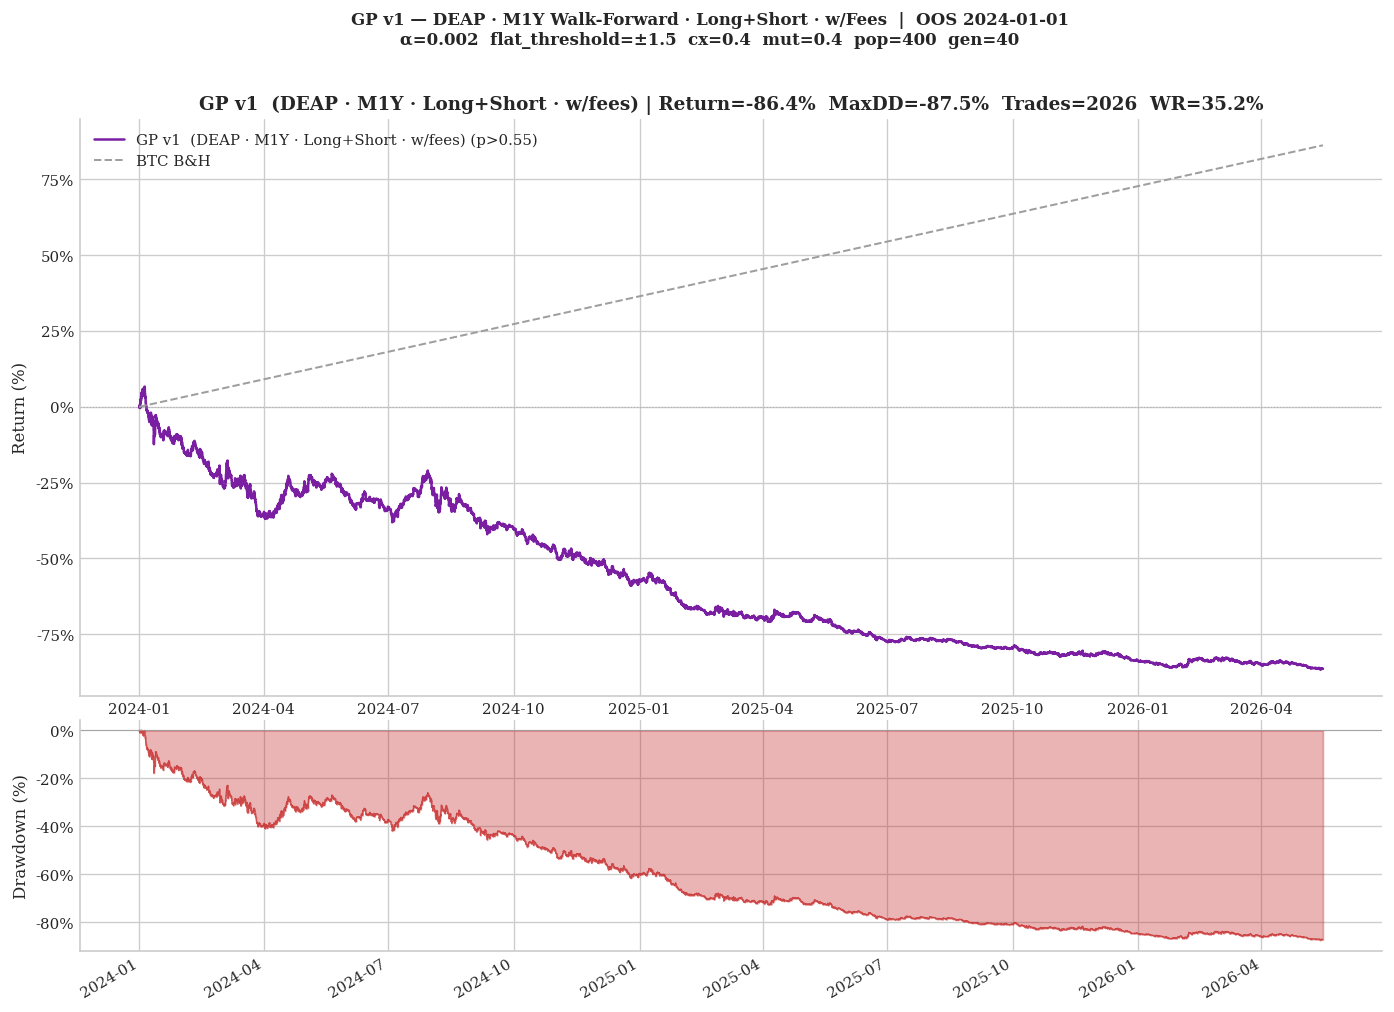

In [7]:
# ── Equity / drawdown plot ────────────────────────────────────────────────────
oos_index = oos_df.index
_oos_end_px   = oos_df['close'].iloc[-1]
_oos_start_px = oos_df['close'].iloc[0]
bh_pct = np.linspace(0., (_oos_end_px / _oos_start_px - 1) * 100, len(oos_index))

fig = plot_equity_drawdown(
    oos_index, eq_fees, tdf_fees,
    bh_pct=bh_pct,
    label='GP v1  (DEAP \u00b7 M1Y \u00b7 Long+Short \u00b7 w/fees)',
    color=PURPLE,
)
fig.suptitle(
    f'GP v1 \u2014 DEAP \u00b7 M1Y Walk-Forward \u00b7 Long+Short \u00b7 w/Fees  |  OOS {OOS_START.date()}\n'
    f'\u03b1={PARSIMONY}  flat_threshold=\u00b1{FLAT_THRESHOLD}  cx={CX_PROB}  mut={MUT_PROB}  '
    f'pop={POP_SIZE}  gen={GENERATIONS}',
    fontsize=10, fontweight='bold',
)
save_fig(fig, ARTS_DIR / '01_equity_drawdown.png')
plt.show()

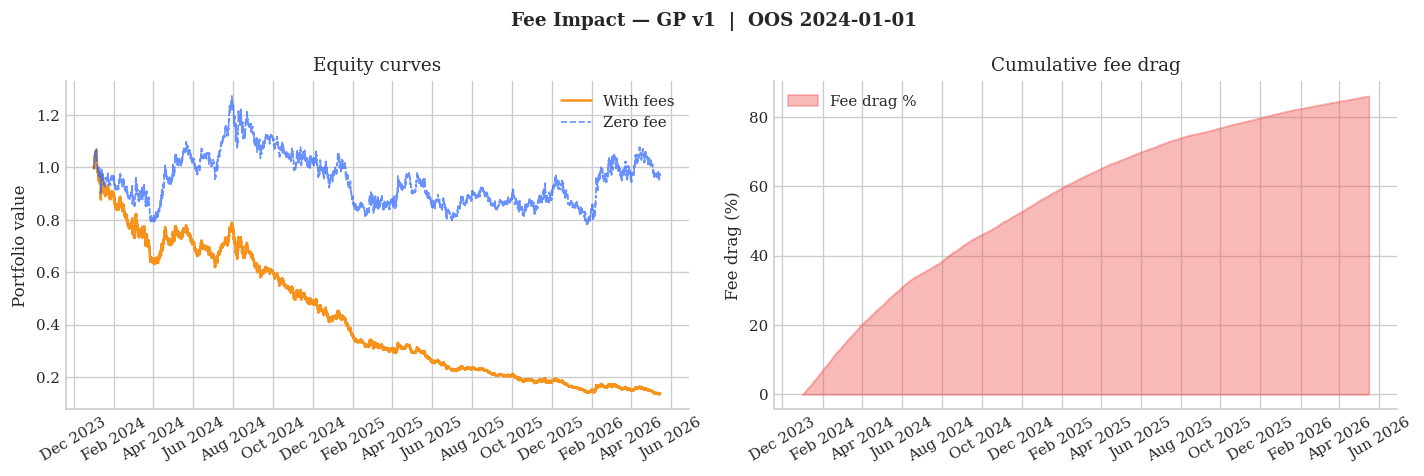

In [8]:
# ── Fee comparison plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(oos_index, eq_fees, color=ACCENT, lw=1.5, label='With fees')
ax.plot(oos_index, eq_0fee, color=BLUE,   lw=1.0, ls='--', alpha=0.7, label='Zero fee')
ax.set_title('Equity curves'); ax.set_ylabel('Portfolio value'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1]
fee_drag = (eq_0fee - eq_fees) / (eq_0fee + 1e-12) * 100
ax.fill_between(oos_index, 0, fee_drag, color=RED, alpha=0.4, label='Fee drag %')
ax.set_title('Cumulative fee drag'); ax.set_ylabel('Fee drag (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30); ax.legend()

fig.suptitle(f'Fee Impact \u2014 GP v1  |  OOS {OOS_START.date()}', fontweight='bold', fontsize=11)
fig.tight_layout()
save_fig(fig, ARTS_DIR / '02_fee_comparison.png')
plt.show()

Monthly stats (w/ fees, full OOS):
  Positive months : 4 / 28
  Avg monthly ret : -6.09%
  Best month      : +14.85%  (Apr 2024)
  Worst month     : -18.97%  (Jan 2025)


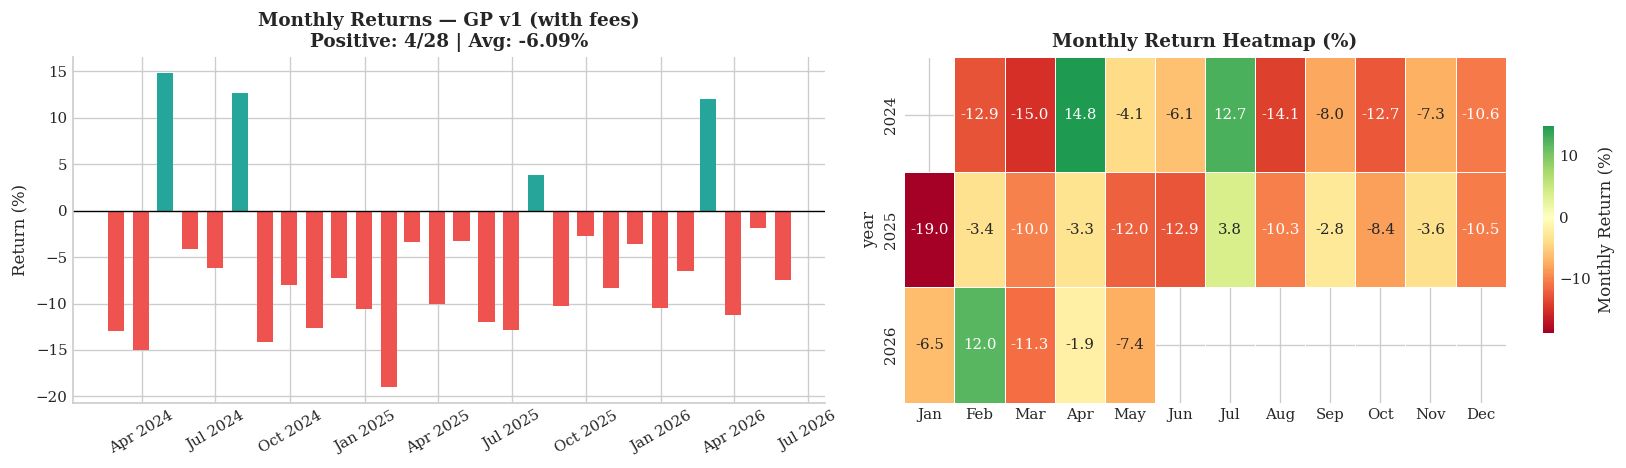

In [9]:
# ── Monthly return analysis ───────────────────────────────────────────────────
eq_full_series = pd.Series(eq_fees, index=oos_index)
monthly_ret = eq_full_series.resample('ME').last().pct_change().dropna() * 100

print('Monthly stats (w/ fees, full OOS):')
print(f'  Positive months : {(monthly_ret>0).sum()} / {len(monthly_ret)}')
print(f'  Avg monthly ret : {monthly_ret.mean():+.2f}%')
print(f'  Best month      : {monthly_ret.max():+.2f}%  ({monthly_ret.idxmax().strftime("%b %Y")})')
print(f'  Worst month     : {monthly_ret.min():+.2f}%  ({monthly_ret.idxmin().strftime("%b %Y")})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
colors_bar = [GREEN if r >= 0 else RED for r in monthly_ret]
ax.bar(monthly_ret.index, monthly_ret.values, color=colors_bar, width=20)
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'Monthly Returns \u2014 GP v1 (with fees)\n'
             f'Positive: {(monthly_ret>0).sum()}/{len(monthly_ret)} | Avg: {monthly_ret.mean():+.2f}%',
             fontweight='bold')
ax.set_ylabel('Return (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1]
pivot_df = monthly_ret.to_frame('ret')
pivot_df['year']  = pivot_df.index.year
pivot_df['month'] = pivot_df.index.month
try:
    heat = pivot_df.pivot(index='year', columns='month', values='ret')
    heat.columns = [calendar.month_abbr[m] for m in heat.columns]
    sns.heatmap(heat, annot=True, fmt='.1f', center=0,
                cmap='RdYlGn', linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.6},
                annot_kws={'size': 9})
    ax.set_title('Monthly Return Heatmap (%)', fontweight='bold')
except Exception as e:
    ax.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax.transAxes)

fig.tight_layout()
save_fig(fig, ARTS_DIR / '03_monthly_returns.png')
plt.show()

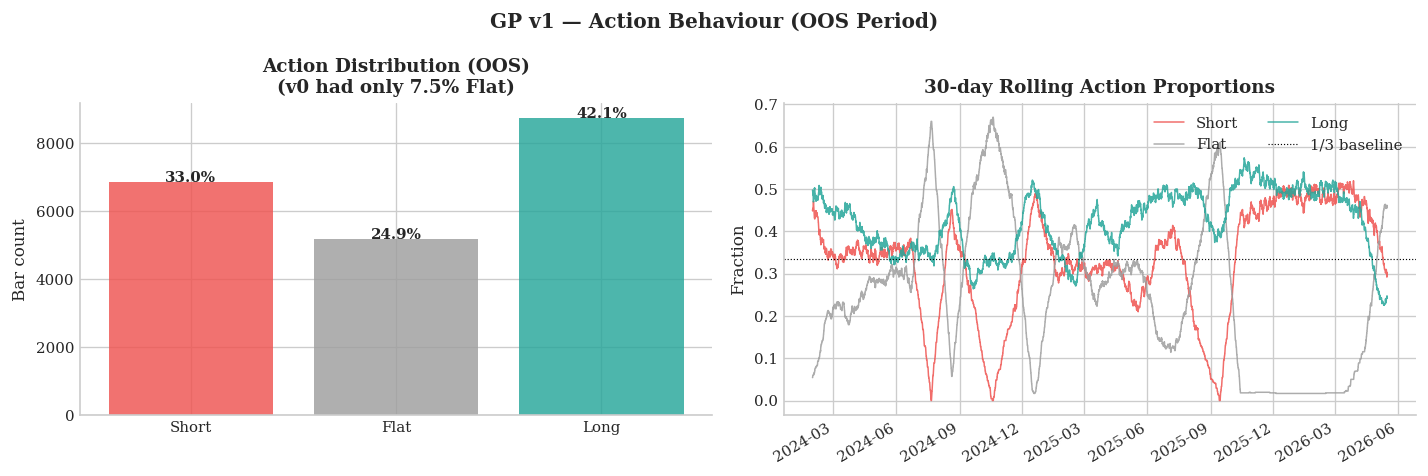

In [10]:
# ── Action distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
act_names = {-1: 'Short', 0: 'Flat', 1: 'Long'}
vc = gp_signals.value_counts().sort_index()
bar_cols = [ac for k in vc.index for ac in [(RED if k==-1 else (GREY if k==0 else GREEN))]]
ax.bar([act_names.get(k, str(k)) for k in vc.index], vc.values, color=bar_cols, alpha=0.82)
for i, (k, v) in enumerate(vc.items()):
    ax.text(i, v + 5, f'{v/len(gp_signals)*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Action Distribution (OOS)\n(v0 had only 7.5% Flat)', fontweight='bold')
ax.set_ylabel('Bar count')

ax = axes[1]
act_series = pd.Series(_acts, index=gp_signals.index)
roll_w = 720
for act_val, col, name in [(-1, RED, 'Short'), (0, GREY, 'Flat'), (1, GREEN, 'Long')]:
    frac = (act_series == act_val).rolling(roll_w).mean()
    ax.plot(frac.index, frac, color=col, lw=0.9, alpha=0.85, label=name)
ax.axhline(1/3, color='black', ls=':', lw=0.7, label='1/3 baseline')
ax.set_title('30-day Rolling Action Proportions', fontweight='bold')
ax.set_ylabel('Fraction'); ax.legend(ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('GP v1 \u2014 Action Behaviour (OOS Period)', fontweight='bold')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '04_action_distribution.png')
plt.show()

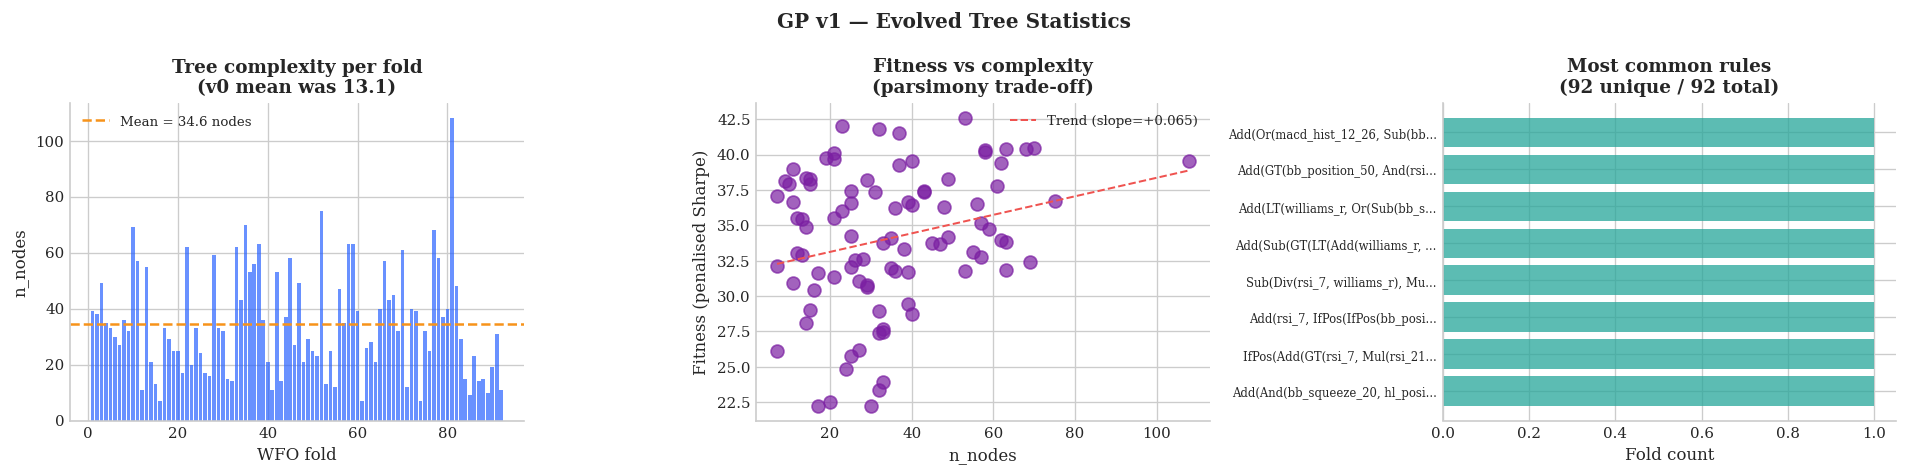

In [11]:
# ── Tree complexity across folds ──────────────────────────────────────────────
if agent.fold_winners:
    fold_nums   = [fw['fold']    for fw in agent.fold_winners]
    fold_nodes  = [fw['n_nodes'] for fw in agent.fold_winners]
    fold_height = [fw['height']  for fw in agent.fold_winners]
    fold_fitness= [fw['fitness'] for fw in agent.fold_winners]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.bar(fold_nums, fold_nodes, color=BLUE, alpha=0.7)
    ax.axhline(np.mean(fold_nodes), color=ACCENT, lw=1.5, ls='--',
               label=f'Mean = {np.mean(fold_nodes):.1f} nodes')
    ax.set_xlabel('WFO fold'); ax.set_ylabel('n_nodes')
    ax.set_title('Tree complexity per fold\n(v0 mean was 13.1)', fontweight='bold')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.scatter(fold_nodes, fold_fitness, color=PURPLE, alpha=0.7, s=60)
    z = np.polyfit(fold_nodes, fold_fitness, 1)
    xr = np.linspace(min(fold_nodes), max(fold_nodes), 50)
    ax.plot(xr, np.polyval(z, xr), color=RED, lw=1.2, ls='--', label=f'Trend (slope={z[0]:+.3f})')
    ax.set_xlabel('n_nodes'); ax.set_ylabel('Fitness (penalised Sharpe)')
    ax.set_title('Fitness vs complexity\n(parsimony trade-off)', fontweight='bold')
    ax.legend(fontsize=8)

    ax = axes[2]
    all_rules = [fw['tree_str'] for fw in agent.fold_winners]
    from collections import Counter
    rule_counts = Counter(all_rules).most_common(8)
    labels = [r[:30]+'...' if len(r)>30 else r for r, _ in rule_counts]
    counts = [c for _, c in rule_counts]
    ax.barh(range(len(counts)), counts, color=GREEN, alpha=0.75)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('Fold count'); ax.set_title(f'Most common rules\n({len(set(all_rules))} unique / {len(all_rules)} total)', fontweight='bold')

    fig.suptitle('GP v1 \u2014 Evolved Tree Statistics', fontweight='bold')
    fig.tight_layout()
    save_fig(fig, ARTS_DIR / '05_tree_complexity.png')
    plt.show()

In [12]:
# ── v0 vs v1 comparison ───────────────────────────────────────────────────────
v0_sig_path     = REPO_DIR / 'artifacts' / '09_gp_omni_0fee_v0' / 'gp_oos_signals.parquet'
v0_results_path = REPO_DIR / 'artifacts' / '09_gp_omni_0fee_v0' / 'results.json'

if v0_sig_path.exists() and v0_results_path.exists():
    with open(v0_results_path) as f:
        v0_res = json.load(f)
    v0m_fee = v0_res['backtest_with_fees']
    v0m_0fe = v0_res['backtest_zero_fee']
    v0_flat_pct = v0_res.get('action_dist', {}).get('0', 0)
    if v0_flat_pct:
        v0_total = sum(v0_res['action_dist'].values())
        v0_flat_pct = v0_flat_pct / v0_total * 100
    else:
        v0_flat_pct = 7.5  # known from v0 run

    v1_flat_pct = (gp_signals == 0).mean() * 100
    v1_wr = (tdf_fees['net'] > 0).mean() if len(tdf_fees) else 0.

    print('\n\u250c' + '\u2500'*63 + '\u2510')
    print(f'\u2502  {"METRIC":<28} {"GP v0":>14} {"GP v1":>14}  \u2502')
    print('\u251c' + '\u2500'*63 + '\u2524')
    print(f'\u2502  {"Trades (OOS)":<28} {v0m_fee["n_trades"]:>14,} {len(tdf_fees):>14,}  \u2502')
    print(f'\u2502  {"Flat % (OOS)":<28} {v0_flat_pct:>13.1f}% {v1_flat_pct:>13.1f}%  \u2502')
    print(f'\u2502  {"Win Rate (w/fees)":<28} {v0m_fee["win_rate"]:>13.1%} {v1_wr:>13.1%}  \u2502')
    print(f'\u2502  {"Return (w/fees)":<28} {v0m_fee["total_return"]:>13.1%} {eq_fees[-1]-1:>13.1%}  \u2502')
    print(f'\u2502  {"Sharpe (w/fees)":<28} {v0m_fee["sharpe"]:>14.3f} {_sharpe(eq_fees):>14.3f}  \u2502')
    print(f'\u2502  {"Max Drawdown":<28} {v0m_fee["max_drawdown"]:>13.1%} {_maxdd(eq_fees):>13.1%}  \u2502')
    print('\u251c' + '\u2500'*63 + '\u2524')
    print(f'\u2502  {"Return (0-fee)":<28} {v0m_0fe["total_return"]:>13.1%} {eq_0fee[-1]-1:>13.1%}  \u2502')
    print(f'\u2502  {"Sharpe (0-fee)":<28} {v0m_0fe["sharpe"]:>14.3f} {_sharpe(eq_0fee):>14.3f}  \u2502')
    print('\u2514' + '\u2500'*63 + '\u2518')
    print()
    # Unique rule count comparison
    if agent.fold_winners:
        all_rules = [fw['tree_str'] for fw in agent.fold_winners]
        print(f'Unique rules: GP v0 had ~17/29 identical  |  GP v1: {len(set(all_rules))}/{len(all_rules)}')
else:
    print('v0 artifacts not found \u2014 run 09_gp_omni_0fee_v0 first for comparison.')
    print(f'\nGP v1 summary  (full OOS, w/ fees):')
    print(f'  Trades  : {len(tdf_fees):,}')
    print(f'  Flat %  : {(gp_signals==0).mean():.1%}')
    print(f'  Return  : {eq_fees[-1]-1:+.2%}')
    print(f'  Sharpe  : {_sharpe(eq_fees):.3f}')
    print(f'  Max DD  : {_maxdd(eq_fees):.2%}')


┌───────────────────────────────────────────────────────────────┐
│  METRIC                                GP v0          GP v1  │
├───────────────────────────────────────────────────────────────┤
│  Trades (OOS)                          2,055          2,026  │
│  Flat % (OOS)                           7.5%          24.9%  │
│  Win Rate (w/fees)                    32.6%         35.2%  │
│  Return (w/fees)                     -87.7%        -86.4%  │
│  Sharpe (w/fees)                      -2.257         -2.231  │
│  Max Drawdown                        -89.4%        -87.5%  │
├───────────────────────────────────────────────────────────────┤
│  Return (0-fee)                      -10.2%         -2.9%  │
│  Sharpe (0-fee)                       -0.118         -0.033  │
└───────────────────────────────────────────────────────────────┘

Unique rules: GP v0 had ~17/29 identical  |  GP v1: 92/92


In [13]:
# ── Save results.json ─────────────────────────────────────────────────────────
def _bt_metrics(eq, tdf, label):
    wr = float((tdf['net']>0).mean()) if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    avg_hold = float(tdf['hold'].mean()) if len(tdf) else 0.
    return {
        'label':        label,
        'n_trades':     len(tdf),
        'n_long':       n_l,
        'n_short':      n_s,
        'win_rate':     round(wr, 4),
        'avg_hold_h':   round(avg_hold, 1),
        'total_return': round(float(eq[-1]-1), 4),
        'sharpe':       round(_sharpe(eq), 4),
        'max_drawdown': round(_maxdd(eq), 4),
    }

all_rules = [fw['tree_str'] for fw in agent.fold_winners] if agent.fold_winners else []

results = {
    'agent':     'GPTradingAgent v1',
    'notebook':  '09_gp_omni_0fee_v1',
    'created':   pd.Timestamp.now().isoformat(),
    'oos_start': str(OOS_START.date()),
    'oos_end':   str(oos_df.index[-1].date()),
    'oos_bars':  len(oos_df),
    'gp_config': {
        'population_size':  POP_SIZE,
        'generations':      GENERATIONS,
        'parsimony_alpha':  PARSIMONY,
        'flat_threshold':   FLAT_THRESHOLD,
        'cx_prob':          CX_PROB,
        'mut_prob':         MUT_PROB,
        'train_window_h':   TRAIN_WINDOW_H,
        'step_size':        STEP_SIZE,
        'n_features':       len(GP_FEATURES),
        'features':         GP_FEATURES,
        'unique_rules':     len(set(all_rules)),
        'total_folds':      len(agent.fold_winners),
        'afml_defences': [
            'Ch.2 feature stationarity — bounded oscillators only',
            'Ch.7 purged fitness — last 12 bars excluded each fold',
            'Ch.14 parsimony pressure — Fitness = Sharpe - α×n_nodes',
        ],
        'v1_fixes': [
            f'flat_threshold=±{FLAT_THRESHOLD} — replaces np.sign(), forces Flat state',
            f'parsimony_alpha 0.010 → {PARSIMONY} — allows richer trees',
            f'cx_prob 0.70 → {CX_PROB}, mut_prob 0.25 → {MUT_PROB} — more diversity',
            f'pop 300 → {POP_SIZE}, gen 30 → {GENERATIONS} — more search',
        ],
    },
    'backtest_with_fees': _bt_metrics(eq_fees, tdf_fees, 'with_fees'),
    'backtest_zero_fee':  _bt_metrics(eq_0fee, tdf_0fee, 'zero_fee'),
    'action_dist': {str(k): int(v) for k, v in gp_signals.value_counts().sort_index().items()},
    'fold_winners': [
        {
            'fold':      fw['fold'],
            'oos_start': str(fw['oos_start'].date()),
            'oos_end':   str(fw['oos_end'].date()),
            'n_nodes':   fw['n_nodes'],
            'height':    fw['height'],
            'fitness':   round(fw['fitness'], 4),
            'tree':      fw['tree_str'],
        }
        for fw in agent.fold_winners
        if fw['oos_start'] >= OOS_START
    ],
}

out_path = ARTS_DIR / 'results.json'
with open(out_path, 'w') as fh:
    json.dump(results, fh, indent=2)
print(f'Saved → {out_path}')

print(f"\n{'='*55}")
print(f"GP v1  OOS {results['oos_start']} → {results['oos_end']}")
print(f"{'='*55}")
m = results['backtest_with_fees']
print(f"Return : {m['total_return']:+.2%}")
print(f"Sharpe : {m['sharpe']:.3f}")
print(f"MaxDD  : {m['max_drawdown']:.2%}")
print(f"Trades : {m['n_trades']}  (L:{m['n_long']} S:{m['n_short']})")
print(f"WinRate: {m['win_rate']:.1%}")
flat_n = results['action_dist'].get('0', 0)
total_n = sum(results['action_dist'].values())
print(f"Flat % : {flat_n/total_n*100:.1f}%")

Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/09_gp_omni_0fee_v1/results.json

GP v1  OOS 2024-01-01 → 2026-05-16
Return : -86.40%
Sharpe : -2.231
MaxDD  : -87.49%
Trades : 2026  (L:1171 S:855)
WinRate: 35.2%
Flat % : 24.9%


In [14]:
# ── Meta-learning integration preview ─────────────────────────────────────────
print('Meta-learning integration check')
print('\u2500'*45)

lgbm_cache = REPO_DIR / 'artifacts' / '02_lgbm_omni_0fee_v12' / 'lgbm_oos_signals.parquet'
drl_cache  = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v2'  / 'drl_oos_signals.parquet'

if lgbm_cache.exists():
    lgbm_signals = pd.read_parquet(lgbm_cache)['lgbm_p_up']
    master = pd.concat([lgbm_signals, gp_signals], axis=1).dropna()
    master.columns = ['lgbm_p_up', 'gp_action']
    print(f'Aligned LGBM+GP bars: {len(master):,}')
    corr = master['lgbm_p_up'].corr(master['gp_action'], method='spearman')
    print(f'Spearman \u03c1 (LGBM vs GP v1): {corr:.3f}')
    if abs(corr) < 0.3:
        print('\u2192 Low correlation \u2014 signal DIVERSITY confirmed (good for ensemble)')
    else:
        print('\u2192 Note: higher correlation reduces ensemble benefit')
else:
    print('LGBM signals not cached yet \u2014 run 02_lgbm_omni_0fee_v12 first.')

if drl_cache.exists():
    drl_signals_v2 = pd.read_parquet(drl_cache)['drl_action']
    master3 = pd.concat([gp_signals, drl_signals_v2], axis=1).dropna()
    master3.columns = ['gp_action', 'drl_action']
    corr_gp_drl = master3['gp_action'].corr(master3['drl_action'], method='spearman')
    print(f'\nSpearman \u03c1 (GP v1 vs DRL v2): {corr_gp_drl:.3f}')
    if abs(corr_gp_drl) < 0.3:
        print('\u2192 Low GP/DRL correlation \u2014 two independent failure modes, valuable for meta-labeling')
    else:
        print('\u2192 Note: GP and DRL signals are correlated')
else:
    print('\nDRL v2 signals not found \u2014 run 07_drl_omni_0fee_v2 first.')

print(f'\ngp_signals dtype: {gp_signals.dtype}, name: {gp_signals.name}')
print('Ready for 08_meta_learning_v0 assembly.')

Meta-learning integration check
─────────────────────────────────────────────
LGBM signals not cached yet — run 02_lgbm_omni_0fee_v12 first.

DRL v2 signals not found — run 07_drl_omni_0fee_v2 first.

gp_signals dtype: int8, name: gp_action
Ready for 08_meta_learning_v0 assembly.
